# Statistical Analysis

## Objective

This notebook investigates the statistical relationships between:

- GDP Growth
- Internet Usage
- Secondary Enrollment

The analysis includes:

1. Correlation Analysis
2. Correlation Heatmap
3. Multiple Linear Regression
4. Model Interpretation

Research Question:

"To what extent do internet penetration and educational attainment influence GDP growth across African countries?"

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

import statsmodels.api as sm

In [4]:
df=pd.read_csv(r"D:\GIT\data-analytics-portfolio\01-world-bank-analysis\data\cleaned_data\africa_data_cleaned.csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               1134 non-null   str    
 1   Country_Code          1134 non-null   str    
 2   Year                  1134 non-null   int64  
 3   GDP_Growth            1134 non-null   float64
 4   Internet_Usage        1134 non-null   float64
 5   Secondary_Enrollment  1109 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 53.3 KB


In [7]:
df.isnull().sum()

Country                  0
Country_Code             0
Year                     0
GDP_Growth               0
Internet_Usage           0
Secondary_Enrollment    25
dtype: int64

In [8]:
analysis_df = df[
    ['GDP_Growth',
     'Internet_Usage',
     'Secondary_Enrollment']
].copy()

In [9]:
analysis_df = analysis_df.dropna()

analysis_df.shape

(1109, 3)

In [10]:
analysis_df.info()

<class 'pandas.DataFrame'>
Index: 1109 entries, 0 to 1133
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GDP_Growth            1109 non-null   float64
 1   Internet_Usage        1109 non-null   float64
 2   Secondary_Enrollment  1109 non-null   float64
dtypes: float64(3)
memory usage: 34.7 KB


## Correlation Analysis

In [11]:
corr_matrix = analysis_df.corr()

corr_matrix

,GDP_Growth,Internet_Usage,Secondary_Enrollment
GDP_Growth,1.000000,-0.121533,0.607341
Internet_Usage,-0.121533,1.000000,-0.106736
Secondary_Enrollment,0.607341,-0.106736,1.000000


In [13]:
#Pearson correlation test 
#Internet vs GDP Growth
corr, p_value = pearsonr(
    analysis_df['Internet_Usage'],
    analysis_df['GDP_Growth']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.12153268927141421
P-value: 4.955314474965104e-05


In [14]:
if p_value < 0.05:
    print("Statistically significant relationship")
else:
    print("No statistically significant relationship")

Statistically significant relationship


In [16]:
# Education vs GDP Growth
corr, p_value = pearsonr(
    analysis_df['Secondary_Enrollment'],
    analysis_df['GDP_Growth']
)

print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Statistically significant relationship")
else:
    print("No statistically significant relationship")

Correlation: 0.6073406870337748
P-value: 9.209034114936521e-113
Statistically significant relationship


In [17]:
# Internet vs Education
corr, p_value = pearsonr(
    analysis_df['Internet_Usage'],
    analysis_df['Secondary_Enrollment']
)

print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Statistically significant relationship")
else:
    print("No statistically significant relationship")

Correlation: -0.1067358042962814
P-value: 0.0003699436133297174
Statistically significant relationship


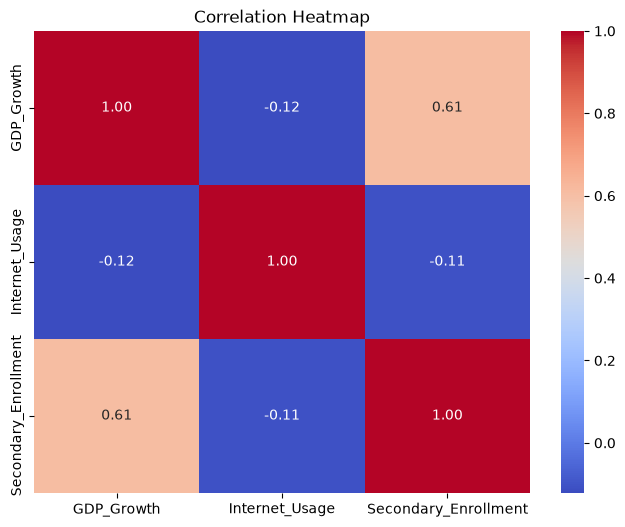

In [18]:
# Correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis Summary

The correlation heatmap reveals a **moderate positive relationship** between **GDP Growth** and **Secondary Enrollment** (**r = 0.61**), suggesting that countries with higher secondary school enrollment rates tend to experience stronger economic growth.

In contrast, **Internet Usage** shows **very weak negative correlations** with both **GDP Growth** (**r = -0.12**) and **Secondary Enrollment** (**r = -0.11**). These correlation values are close to zero, indicating little to no meaningful linear relationship between these variables in the dataset.

Overall, **Secondary Enrollment appears to be the variable most strongly associated with GDP Growth**, while Internet Usage does not demonstrate a significant relationship with either GDP Growth or Secondary Enrollment. However, it is important to note that **correlation does not imply causation**, and further analysis would be required to establish any causal relationships.

In [19]:
# Building and fitting model
X = analysis_df[
    ['Internet_Usage',
     'Secondary_Enrollment']
]

y = analysis_df['GDP_Growth']

X = sm.add_constant(X)

model = sm.OLS(y, X)

results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             GDP_Growth   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     327.7
Date:                Sun, 30 Aug 2026   Prob (F-statistic):          1.69e-112
Time:                        18:42:49   Log-Likelihood:                -4658.7
No. Observations:                1109   AIC:                             9323.
Df Residuals:                    1106   BIC:                             9338.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -6.1567 

# Summary of OLS Regression Findings

## Overview

An Ordinary Least Squares (OLS) regression model was used to examine the relationship between **GDP Growth** and two explanatory variables:

- Internet Usage
- Secondary School Enrollment

The model was based on **1,109 observations** and was found to be statistically significant overall.

---

## Model Performance

- **R² = 0.372**
- **Adjusted R² = 0.371**
- **F-statistic = 327.7**
- **p < 0.001**

The model explains approximately **37.2% of the variation in GDP growth**, indicating moderate explanatory power. The highly significant F-statistic suggests that the predictors jointly contribute to explaining GDP growth.

---

## Effects of Independent Variables

### Secondary School Enrollment

- **Coefficient (β) = 0.490**
- **p < 0.001**

Secondary school enrollment has a **strong positive and statistically significant relationship** with GDP growth. Holding other variables constant, a one-unit increase in secondary enrollment is associated with an estimated **0.49-unit increase in GDP growth**.

This finding suggests that improvements in educational participation are linked to stronger economic performance.

### Internet Usage

- **Coefficient (β) = -0.179**
- **p = 0.017**

Internet usage shows a **negative but statistically significant relationship** with GDP growth. Holding secondary enrollment constant, a one-unit increase in internet usage is associated with an estimated **0.18-unit decrease in GDP growth**.

Although statistically significant, this result is somewhat unexpected and may reflect factors such as differences between developed and developing economies, omitted variables, or other structural relationships within the data.

---

## Diagnostic Results

### Autocorrelation

- **Durbin-Watson = 0.254**

The Durbin-Watson statistic is substantially below the ideal value of 2, indicating **strong positive autocorrelation** in the residuals. This suggests that the assumption of independent errors may be violated.

### Normality of Residuals

- **Jarque-Bera = 216.925**
- **p < 0.001**
- **Skewness = 0.796**
- **Kurtosis = 4.470**

The residuals are not normally distributed and exhibit positive skewness and heavier tails than a normal distribution. This indicates the presence of outliers or extreme observations.

### Multicollinearity

- **Condition Number = 123**

The condition number suggests some potential multicollinearity concerns, although there is no evidence of severe multicollinearity. Further testing using Variance Inflation Factors (VIFs) is recommended.

---

## Conclusion

The regression analysis demonstrates that **secondary school enrollment is a strong and positive predictor of GDP growth**, while **internet usage is negatively associated with GDP growth** in the model. Overall, the model is statistically significant and explains a moderate proportion of the variation in economic growth. However, diagnostic tests reveal issues related to autocorrelation and non-normal residuals, suggesting that more advanced econometric techniques, such as panel-data or time-series models, may improve the reliability of the results.

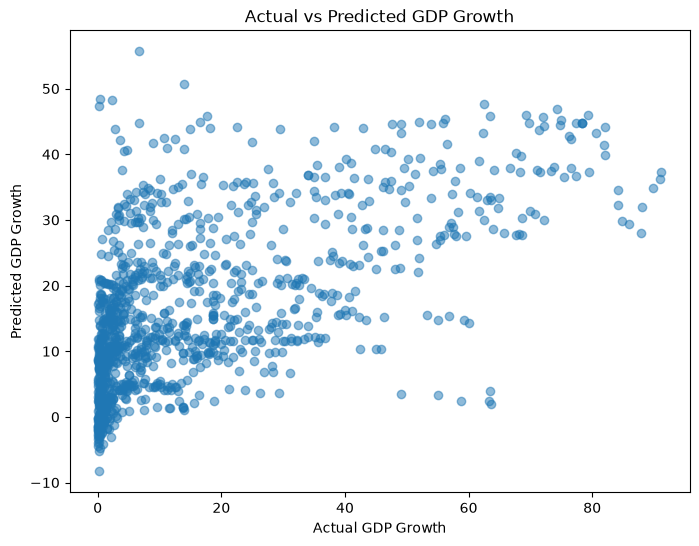

In [20]:


predictions = results.predict(X)

plt.figure(figsize=(8,6))

plt.scatter(
    y,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual GDP Growth")
plt.ylabel("Predicted GDP Growth")

plt.title("Actual vs Predicted GDP Growth")

plt.show()

## Actual vs Predicted GDP Growth

The scatter plot compares the actual GDP growth values with those predicted by the multiple linear regression model. If the model perfectly predicted GDP growth, all observations would lie along a 45-degree diagonal line where actual and predicted values are equal.

The plot shows a general positive relationship between actual and predicted GDP growth, indicating that the model captures some of the underlying variation in economic growth across African countries. As actual GDP growth increases, predicted GDP growth also tends to increase.

However, the observations are widely dispersed rather than tightly clustered around the expected diagonal line. This suggests that the model has substantial prediction errors and does not fully explain the variation in GDP growth. The model appears to perform better for moderate GDP growth values but struggles to accurately predict extreme values.

The model also tends to underestimate countries with very high GDP growth rates. While actual GDP growth reaches values above 80 percent in some observations, predicted values rarely exceed 45 percent. This indicates that important factors influencing economic growth are not captured by the current model.

Overall, the scatter plot suggests that Internet Usage and Secondary Enrollment provide some explanatory power for GDP growth, but they are insufficient to fully explain economic performance across African countries. Additional variables such as investment levels, political stability, trade activity, inflation, natural resource dependence, and government policies may improve the model's predictive accuracy.

### Key Insight

The regression model identifies a positive relationship between the explanatory variables and GDP growth, but the large spread of points indicates that a significant proportion of GDP growth variation remains unexplained. Therefore, the results should be interpreted as evidence of association rather than strong predictive capability.

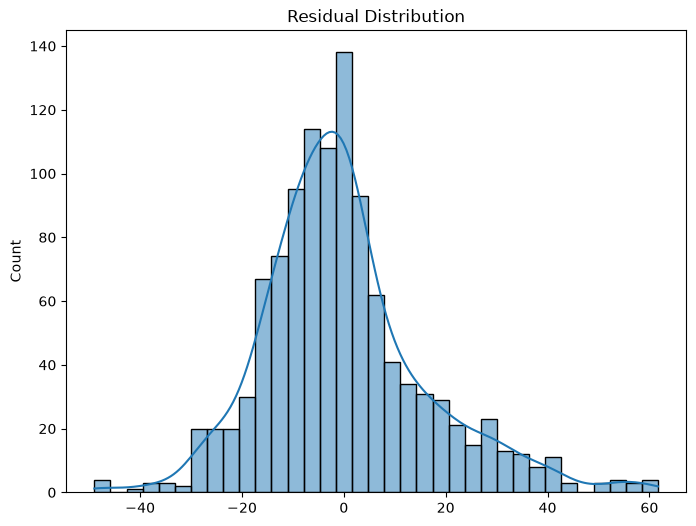

In [21]:
# Residual Analysis
residuals = y - predictions

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

## Residual Analysis

The residual distribution is approximately bell-shaped and centered around zero, suggesting that the regression model's errors are reasonably normally distributed.

However, the distribution shows slight positive skewness and a few extreme residual values on both ends of the distribution. These outliers indicate that the model does not perfectly explain all observations and that additional factors may influence GDP growth.

Overall, the residual plot suggests that the normality assumption is reasonably satisfied, making the regression results suitable for interpretation. Nevertheless, caution should be exercised when interpreting predictions for countries with unusually high or low GDP growth rates.